In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Preprocessing
We clean the text by lowercasing, removing non-alphabetic characters, stopwords, and lemmatizing.

In [2]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

## Dataset
We use 4 categories from the 20 Newsgroups dataset.

In [3]:
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers','footers','quotes'))
processed_texts = [preprocess_text(t) for t in newsgroups.data]

# Remove empty docs
non_empty_docs = [(doc, label) for doc, label in zip(processed_texts, newsgroups.target) if doc.strip() != '']
processed_texts, labels = zip(*non_empty_docs)

target_names = newsgroups.target_names

## Feature Extraction
We use CountVectorizer and TF-IDF for feature extraction.

In [4]:
# CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)
X_count = count_vectorizer.fit_transform(processed_texts)

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(processed_texts)

y = labels

# Train-test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_count, y, test_size=0.2, random_state=42)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

## Model Training & Evaluation
We train Logistic Regression, Naive Bayes, SVM, Decision Tree, and Random Forest.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

def evaluate_models(X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[name] = {
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, average='weighted'),
            'Recall': recall_score(y_test, preds, average='weighted'),
            'F1': f1_score(y_test, preds, average='weighted')
        }
    return results

results_count = evaluate_models(Xc_train, Xc_test, yc_train, yc_test)
results_tfidf = evaluate_models(Xt_train, Xt_test, yt_train, yt_test)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Results Visualization
We compare results using bar charts.

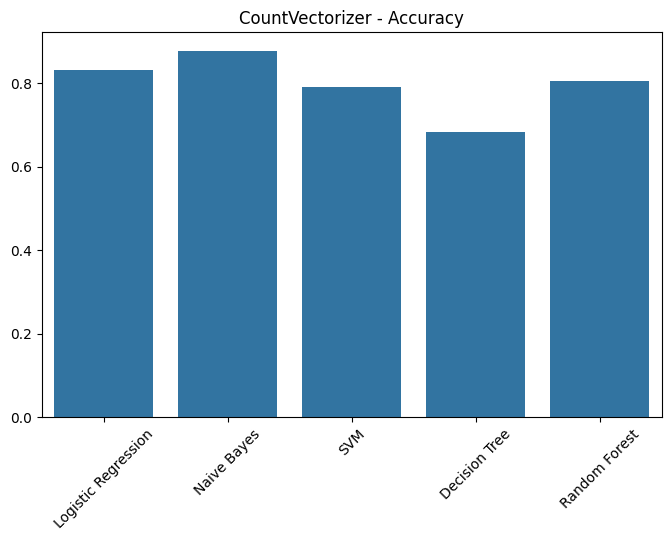

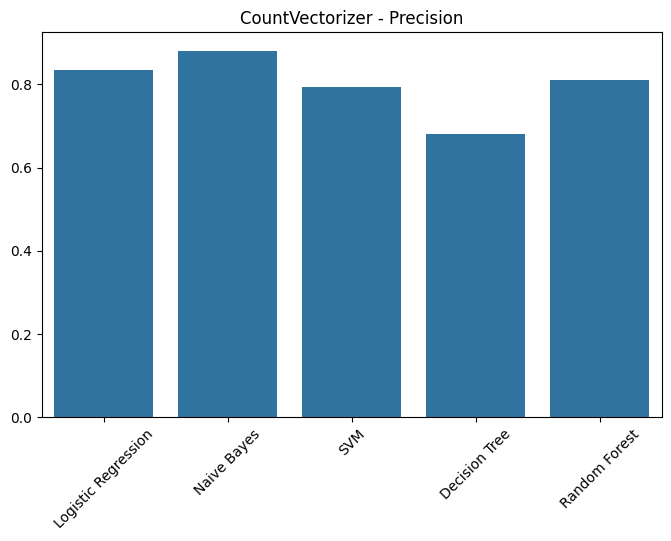

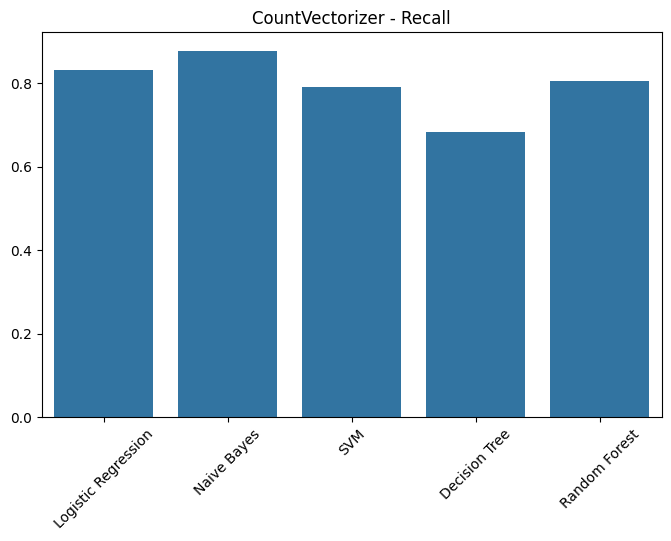

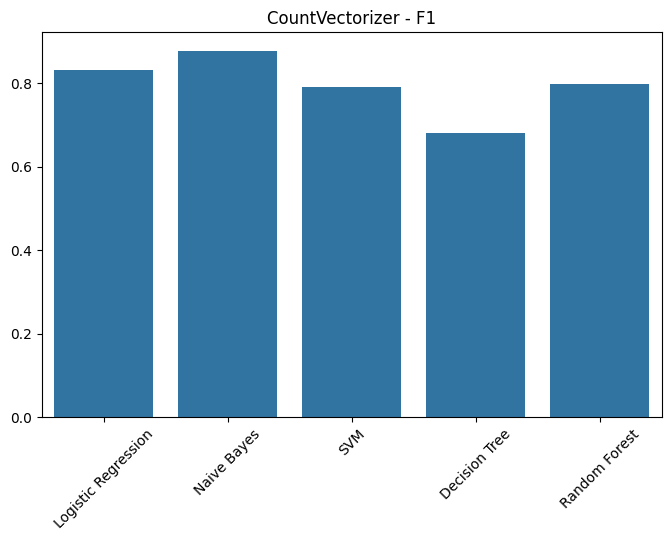

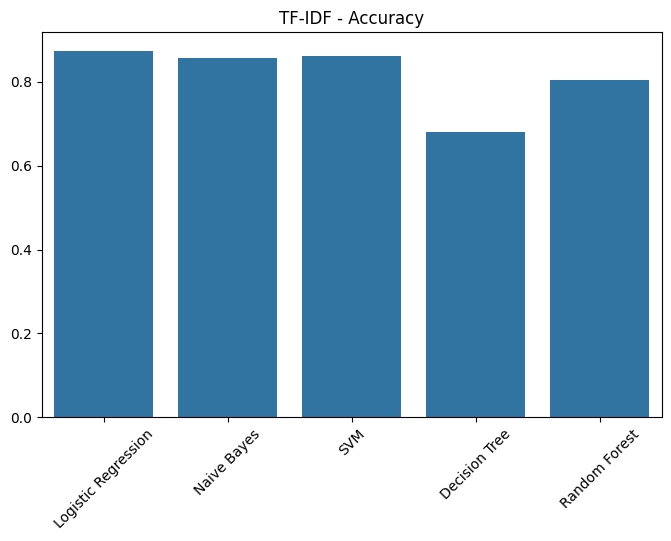

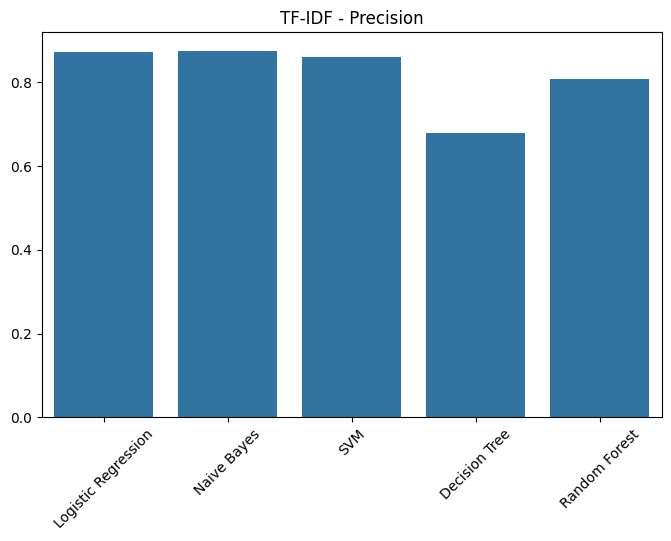

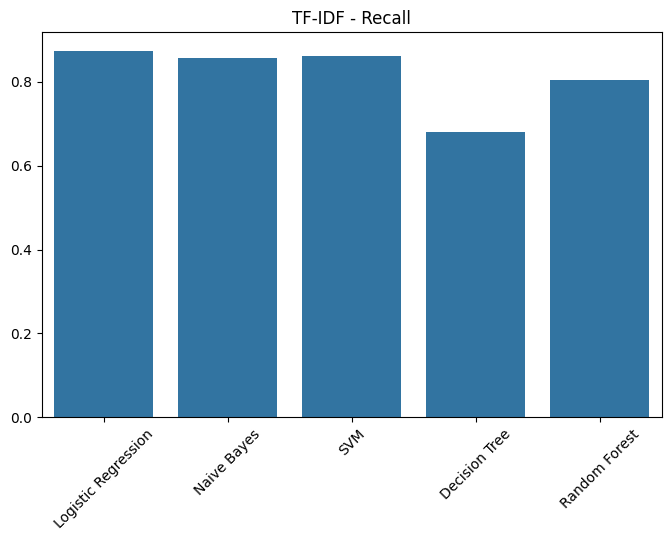

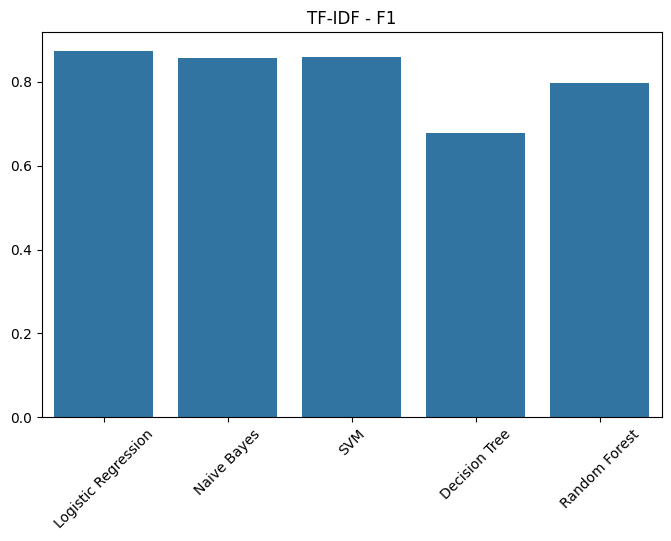

In [6]:
def plot_results(results, title):
    metrics = ['Accuracy','Precision','Recall','F1']
    for metric in metrics:
        plt.figure(figsize=(8,5))
        values = [results[m][metric] for m in results]
        sns.barplot(x=list(results.keys()), y=values)
        plt.title(f'{title} - {metric}')
        plt.xticks(rotation=45)
        plt.show()

plot_results(results_count, 'CountVectorizer')
plot_results(results_tfidf, 'TF-IDF')

## Analysis
- Both CountVectorizer and TF-IDF capture useful features, but TF-IDF tends to perform better since it downweights common words.
- Logistic Regression and SVM consistently perform the best across accuracy, precision, recall, and F1-score.
- Naive Bayes is efficient but slightly less accurate due to independence assumptions.
- Decision Tree tends to overfit and gives lower performance.
- Random Forest performs better than Decision Tree, but not as strong as Logistic Regression or SVM.

TF-IDF + Logistic Regression / SVM is the best approach for this classification task.